## Task 1: Data Preprocessing

### Import Necessary Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

### Load the data & keep the relevant column

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Read the training, testing, and validation datasets from LIAR dataset
train = pd.read_csv("/content/drive/MyDrive/FactOrFiction/train.tsv", sep="\t", header=None)
validation = pd.read_csv("/content/drive/MyDrive/FactOrFiction/valid.tsv", sep="\t", header=None)
test = pd.read_csv("/content/drive/MyDrive/FactOrFiction/test.tsv", sep="\t", header=None)

In [4]:
# Print the data
print(train.head())
print(validation.head())
print(test.head())

           0            1                                                  2   \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                                   3               4                     5   \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

         6           7     8     9    

In [5]:
# Check the shapes of the datasets
print("Shape of TRAIN DATA: ", train.shape)
print("Shape of VALIDATION DATA: ", validation.shape)
print("Shape of TEST DATA: ", test.shape)

Shape of TRAIN DATA:  (10240, 14)
Shape of VALIDATION DATA:  (1284, 14)
Shape of TEST DATA:  (1267, 14)


In [6]:
# Keep every column except 6
train = train[[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]]
validation = validation[[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]]
test = test[[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]]

cols = ['label', 'statement', 'subject', 'speaker', 'job', 'party', 'pants_fire_counts', 'false_counts', 'barely_true_counts', 'half_true_counts', 'true_counts']
train.columns = cols
validation.columns = cols
test.columns = cols

In [7]:
# Print the updated data
print(train.head())
print(validation.head())
print(test.head())

         label                                          statement  \
0        false  Says the Annies List political group supports ...   
1    half-true  When did the decline of coal start? It started...   
2  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3        false  Health care reform legislation is likely to ma...   
4    half-true  The economic turnaround started at the end of ...   

                              subject         speaker                   job  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

        party  pants_fire_counts  false_counts  barely_true_counts  \
0  republican                0.0        

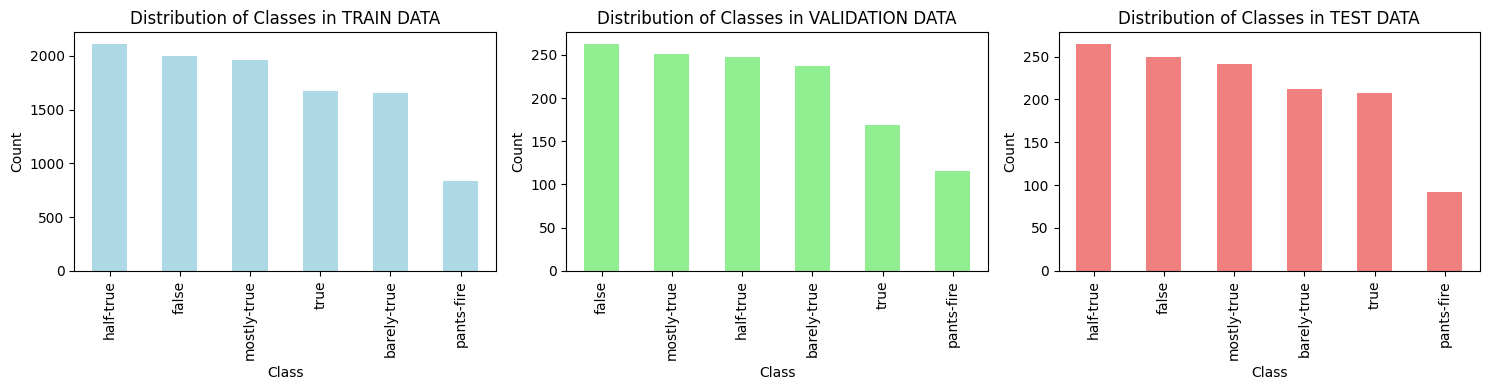

In [8]:
# Plot the distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train['label'].value_counts().plot(kind='bar', ax=axes[0], color='lightblue')
axes[0].set_title('Distribution of Classes in TRAIN DATA')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

validation['label'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Classes in VALIDATION DATA')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

test['label'].value_counts().plot(kind='bar', ax=axes[2], color='lightcoral')
axes[2].set_title('Distribution of Classes in TEST DATA')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')


plt.tight_layout()
plt.show()

### Data Cleaning
Reference: https://www.geeksforgeeks.org/machine-learning/python-efficient-text-data-cleaning/

In [9]:
train_clean = train.copy()
validation_clean = validation.copy()
test_clean = test.copy()

In [10]:
def combine_fields(row):
    # Use every field except 6
    parts = [
      f"speaker: {row['speaker']}",
      f"party: {row['party']}",
      f"job: {row['job']}",
      f"subject: {row['subject']}",
      f"history: {row['pants_fire_counts']} pants-fire, {row['false_counts']} false, {row['barely_true_counts']} barely-true, {row['half_true_counts']} half-true, {row['true_counts']} true",
      f"statement: {row['statement']}"
    ]
    # Handle NaN values gracefully
    parts = [p for p in parts if 'nan' not in p.lower()]
    return ' '.join(parts)

train_clean['text'] = train.apply(combine_fields, axis=1)
validation_clean['text'] = validation.apply(combine_fields, axis=1)
test_clean['text'] = test.apply(combine_fields, axis=1)

In [11]:
def clean_text(text):
    # Step 1: Convert all text to lowercase, remove punctuation and remove whitespace
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join(text.split())

    # Step 2: Remove URLs and Hashtags
    text = re.sub(r'https?:\/\/.\S+', "", text)
    text = re.sub(r'#', '', text)

    # Step 3: Contration Replacement (didn't to did not)
    shorten_dict={"'s":" is","n't":" not","'m":" am","'ll":" will",
           "'d":" would","'ve":" have","'re":" are"}
    for key, value in shorten_dict.items():
        if key in text:
            text = text.replace(key, value)

    return text

In [12]:
train_clean['text'] = train_clean['text'].apply(clean_text)
validation_clean['text'] = validation_clean['text'].apply(clean_text)
test_clean['text'] = test_clean['text'].apply(clean_text)

In [13]:
print(train_clean)

             label                                          statement  \
0            false  Says the Annies List political group supports ...   
1        half-true  When did the decline of coal start? It started...   
2      mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3            false  Health care reform legislation is likely to ma...   
4        half-true  The economic turnaround started at the end of ...   
...            ...                                                ...   
10235  mostly-true  There are a larger number of shark attacks in ...   
10236  mostly-true  Democrats have now become the party of the [At...   
10237    half-true  Says an alternative to Social Security that op...   
10238        false  On lifting the U.S. Cuban embargo and allowing...   
10239   pants-fire  The Department of Veterans Affairs has a manua...   

                                  subject         speaker  \
0                                abortion    dwayne-bohac   
1

In [14]:
print(train_clean['text'])

0        speaker dwaynebohac party republican job state...
1        speaker scottsurovell party democrat job state...
2        speaker barackobama party democrat job preside...
3        speaker blogposting party none subject healthc...
4        speaker charliecrist party democrat subject ec...
                               ...                        
10235    speaker acluflorida party none subject animals...
10236    speaker alanpowell party republican subject el...
10237    speaker hermancain party republican subject re...
10238    speaker jeffgreene party democrat subject flor...
10239    speaker michaelsteele party republican job cha...
Name: text, Length: 10240, dtype: object


In [15]:
print("Train distribution:")
print(train_clean['label'].value_counts())
print(train_clean['label'].value_counts(normalize=True))

print("\nTest distribution:")
print(test_clean['label'].value_counts())
print(test_clean['label'].value_counts(normalize=True))

Train distribution:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64
label
half-true      0.206445
false          0.194824
mostly-true    0.191602
true           0.163672
barely-true    0.161523
pants-fire     0.081934
Name: proportion, dtype: float64

Test distribution:
label
half-true      265
false          249
mostly-true    241
barely-true    212
true           208
pants-fire      92
Name: count, dtype: int64
label
half-true      0.209155
false          0.196527
mostly-true    0.190213
barely-true    0.167324
true           0.164167
pants-fire     0.072612
Name: proportion, dtype: float64


In [16]:
import pandas as pd

# Show full content of each column
pd.set_option('display.max_colwidth', None)

# Now print the DataFrame
print(train.head())

         label  \
0        false   
1    half-true   
2  mostly-true   
3        false   
4    half-true   

                                                                                                                                       statement  \
0                                                             Says the Annies List political group supports third-trimester abortions on demand.   
1  When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.   
2                                      Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."   
3                                                                 Health care reform legislation is likely to mandate free sex change surgeries.   
4                                                                                         The economic turnaround started at the end of my term.   

  

In [17]:
import pandas as pd

# Show full content of each column
pd.set_option('display.max_colwidth', None)

# Now print the DataFrame
print(train_clean.head())

         label  \
0        false   
1    half-true   
2  mostly-true   
3        false   
4    half-true   

                                                                                                                                       statement  \
0                                                             Says the Annies List political group supports third-trimester abortions on demand.   
1  When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.   
2                                      Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."   
3                                                                 Health care reform legislation is likely to mandate free sex change surgeries.   
4                                                                                         The economic turnaround started at the end of my term.   

  

## Task 2: BiLSTM Baseline


Reference: https://www.geeksforgeeks.org/nlp/bidirectional-lstm-in-nlp/ -> but ours are not just true or false so we can't use vectorization


### Encode Labels
Convert the labels such as false, true, etc. into numbers


In [18]:
from sklearn.preprocessing import LabelEncoder
""" Old (6-class) classifications
label_encoder = LabelEncoder()

train_labels = label_encoder.fit_transform(train_clean[1])
val_labels = label_encoder.transform(validation_clean[1])
test_labels = label_encoder.transform(test_clean[1])
"""
# New binary label mappings:
label_map = {
    'pants-fire': 0,
    'false':      0,
    'barely-true':0,
    'half-true':  1,
    'mostly-true':1,
    'true':       1
}

train_labels      = train_clean['label'].map(label_map).values
val_labels        = validation_clean['label'].map(label_map).values
test_labels       = test_clean['label'].map(label_map).values

#print(label_encoder.classes_)

### Tokenization

In [19]:
MAX_VOCAB = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_clean['text'])

train_seq = tokenizer.texts_to_sequences(train_clean['text'])
val_seq = tokenizer.texts_to_sequences(validation_clean['text'])
test_seq = tokenizer.texts_to_sequences(test_clean['text'])

train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post')
val_pad = pad_sequences(val_seq, maxlen=MAX_LEN, padding='post')
test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post')

### Train the BiLSTM
Reference: https://medium.com/@anishnama20/understanding-bidirectional-lstm-for-sequential-data-processing-b83d6283befc

In [20]:
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense

# Define the model architecture
model = Sequential()

# Add an embedding layer to convert input sequences to dense vectors
model.add(Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN))

# Add a Bidirectional LSTM layer
model.add(Bidirectional(LSTM(units=64, return_sequences=False)))

# Add a dense output layer
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) # Changed with binary classification

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    train_pad, train_labels,
    validation_data=(val_pad, val_labels),
    epochs=5,
    batch_size=32
)

Epoch 1/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6138 - loss: 0.6488 - val_accuracy: 0.5974 - val_loss: 0.6573
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7329 - loss: 0.5186 - val_accuracy: 0.5888 - val_loss: 0.7642
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8136 - loss: 0.3985 - val_accuracy: 0.5771 - val_loss: 0.9765
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8632 - loss: 0.3059 - val_accuracy: 0.5717 - val_loss: 1.1776
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9103 - loss: 0.2141 - val_accuracy: 0.5670 - val_loss: 1.2236


In [22]:
test_loss, test_acc = model.evaluate(test_pad, test_labels)
print(f"Test Accuracy: {test_acc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5841 - loss: 1.1358
Test Accuracy: 0.5841


## Task 3: BERT

Reference:

- https://medium.com/@info.codetitan/analyzing-fake-news-with-transformers-484b537c6f0e
- https://medium.com/@piyushkashyap045/guide-to-tokenization-and-padding-with-bert-transforming-text-into-machine-readable-data-5a24bf59d36b

- https://medium.com/data-science/a-complete-guide-to-bert-with-code-9f87602e4a11 (most relevant to the code)

### Tokenize the text

In [23]:
# Load a BERT tokenizer
""" Changed for Roberta-large
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
"""
bert_tokenizer = RobertaTokenizer.from_pretrained("roberta-large") # Change 9
# Tokenize the training data
train_tokens = bert_tokenizer(
    train_clean['text'].tolist(),
    padding=True,
    truncation=True,
    max_length = 128)

# Tokenize the validation data
val_tokens = bert_tokenizer(
    validation_clean['text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length = 128)

# Tokenize the test data
test_tokens = bert_tokenizer(
    test_clean['text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length = 128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [24]:
def make_dataloader(tokens, labels, batch_size=32, shuffle=True):
    input_ids      = torch.tensor(tokens["input_ids"])
    attention_mask = torch.tensor(tokens["attention_mask"])
    label_tensor   = torch.tensor(labels)
    dataset = TensorDataset(input_ids, attention_mask, label_tensor)
    sampler = RandomSampler(dataset) if shuffle else SequentialSampler(dataset)
    return DataLoader(dataset, sampler=sampler, batch_size=batch_size)

train_dataloader = make_dataloader(train_tokens, train_labels, shuffle=True)
val_dataloader   = make_dataloader(val_tokens,   val_labels,   shuffle=False)
test_dataloader  = make_dataloader(test_tokens,  test_labels,  shuffle=False)

### Train the BERT model

In [25]:
from torch.optim import AdamW
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup

EPOCHS = 10 # Change as needed
device = torch.device("cuda")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model - Bert Model
"""
bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2 ) # Changed for binary and for dropout
"""
# Load model - RoBERTa
bert_model = RobertaForSequenceClassification.from_pretrained(
    'roberta-large',
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2
)

bert_model.to(device)

"""
# Freeze bottom 6 layers
for name, param in bert_model.named_parameters():
    if any(f"encoder.layer.{i}." in name for i in range(6)):
        param.requires_grad = False

# Optimizer with freezing
optimizer = AdamW(
    filter(lambda p: p.requires_grad, bert_model.parameters()),
    lr=2e-5
)
"""
# Optimizer with differential learning rates
optimizer = AdamW([
    #{"params": bert_model.bert.parameters(), "lr": 2e-5},
    {"params": bert_model.roberta.parameters(), "lr": 1e-5}, # Change 9
    {"params": bert_model.classifier.parameters(), "lr": 1e-3}
])


# Loss function
loss_function = nn.CrossEntropyLoss()

# Scheduler
num_training_steps = EPOCHS * len(train_dataloader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
def calculate_accuracy(preds, labels):
    """ Calculate the accuracy of model predictions against true labels.

    Parameters:
        preds (np.array): The predicted label from the model
        labels (np.array): The true label

    Returns:
        accuracy (float): The accuracy as a percentage of the correct
            predictions.
    """
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    accuracy = np.sum(pred_flat == labels_flat) / len(labels_flat)

    return accuracy

In [27]:
# Training loop
best_val_loss = float('inf')
patience = 3
epochs_without_improvement = 0
for epoch in range(0, EPOCHS):
    print(f"Epoch: {epoch+1}/{EPOCHS}")
    bert_model.train()
    training_loss = 0
    training_accuracy = 0

    for batch in train_dataloader:

        batch_token_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        bert_model.zero_grad()

        loss, logits = bert_model(
            batch_token_ids,
            token_type_ids = None,
            attention_mask=batch_attention_mask,
            labels=batch_labels,
            return_dict=False)

        training_loss += loss.item()
        logits_np = logits.detach().cpu().numpy()
        labels_np = batch_labels.detach().cpu().numpy()
        training_accuracy += calculate_accuracy(logits_np, labels_np)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    average_train_loss = training_loss / len(train_dataloader)
    avg_train_acc = training_accuracy / len(train_dataloader)

    # Model validation
    bert_model.eval()
    val_loss = 0
    val_accuracy = 0

    for batch in val_dataloader:

        batch_token_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        with torch.no_grad():
            (loss, logits) = bert_model(
                batch_token_ids,
                attention_mask = batch_attention_mask,
                labels = batch_labels,
                token_type_ids = None,
                return_dict=False)

        logits = logits.detach().cpu().numpy()
        label_ids = batch_labels.to('cpu').numpy()
        val_loss += loss.item()
        val_accuracy += calculate_accuracy(logits, label_ids)

    average_val_accuracy = val_accuracy / len(val_dataloader)
    average_val_loss = val_loss / len(val_dataloader)
    # Stop training when validation loss gets worse
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        torch.save(bert_model.state_dict(), 'best_model.pt')
        epochs_without_improvement = 0
        print(f"New best model saved!")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"Training Loss: {average_train_loss:.4f}")
    print(f"Training Accuracy: {avg_train_acc:.4f}")
    print(f"Validation Loss: {average_val_loss:.4f}")
    print(f"Validation Accuracy: {average_val_accuracy:.4f}")


Epoch: 1/10
New best model saved!
Training Loss: 0.7083
Training Accuracy: 0.5437
Validation Loss: 0.7789
Validation Accuracy: 0.5198
Epoch: 2/10
New best model saved!
Training Loss: 0.6219
Training Accuracy: 0.6421
Validation Loss: 0.5522
Validation Accuracy: 0.7027
Epoch: 3/10
Training Loss: 0.5378
Training Accuracy: 0.7155
Validation Loss: 0.6343
Validation Accuracy: 0.6082
Epoch: 4/10
New best model saved!
Training Loss: 0.5132
Training Accuracy: 0.7266
Validation Loss: 0.5072
Validation Accuracy: 0.7332
Epoch: 5/10
Training Loss: 0.5076
Training Accuracy: 0.7279
Validation Loss: 0.5237
Validation Accuracy: 0.7233
Epoch: 6/10
Training Loss: 0.4867
Training Accuracy: 0.7475
Validation Loss: 0.5417
Validation Accuracy: 0.7226
Epoch: 7/10
Early stopping at epoch 7


In [28]:
bert_model.load_state_dict(torch.load('best_model.pt'))
bert_model.eval()
test_accuracy = 0

for batch in test_dataloader:
    batch_token_ids = batch[0].to(device)
    batch_attention_mask = batch[1].to(device)
    batch_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = bert_model(
            input_ids=batch_token_ids,
            attention_mask=batch_attention_mask
        )

    logits = outputs.logits
    logits = logits.detach().cpu().numpy()
    label_ids = batch_labels.cpu().numpy()

    test_accuracy += calculate_accuracy(logits, label_ids)

print(f"Test Accuracy: {test_accuracy / len(test_dataloader):.4f}")

Test Accuracy: 0.7499


<Figure size 800x600 with 0 Axes>

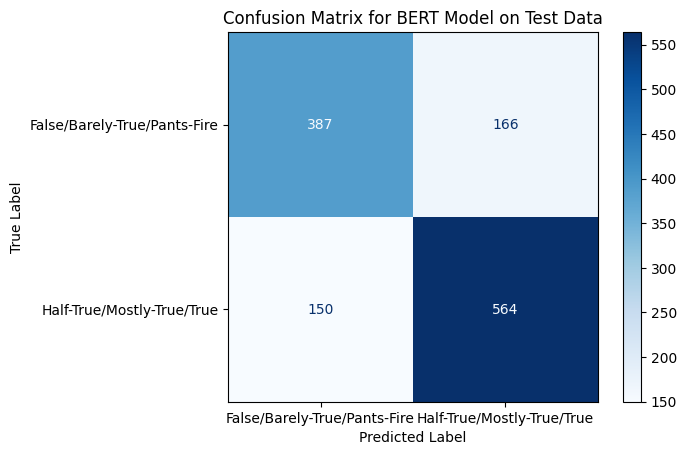

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions for the test set
bert_model.eval()
all_predictions = []
all_true_labels = []

for batch in test_dataloader:
    batch_token_ids = batch[0].to(device)
    batch_attention_mask = batch[1].to(device)
    batch_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = bert_model(
            input_ids=batch_token_ids,
            attention_mask=batch_attention_mask
        )

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1).cpu().numpy()
    true_labels = batch_labels.cpu().numpy()

    all_predictions.extend(predictions)
    all_true_labels.extend(true_labels)

# Calculate the confusion matrix
cm = confusion_matrix(all_true_labels, all_predictions)

# Define class labels for the confusion matrix (0 for 'false' categories, 1 for 'true' categories)
class_names = ['False/Barely-True/Pants-Fire', 'Half-True/Mostly-True/True']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for BERT Model on Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

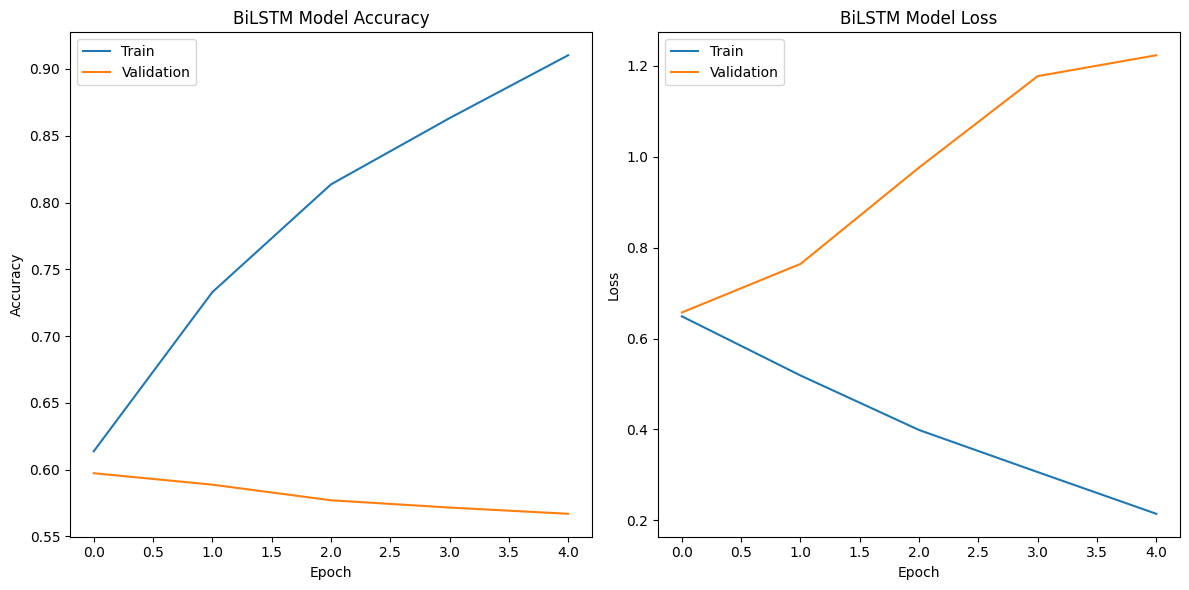

In [30]:
import matplotlib.pyplot as plt

# Plotting for BiLSTM model (using 'history' object)
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('BiLSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('BiLSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

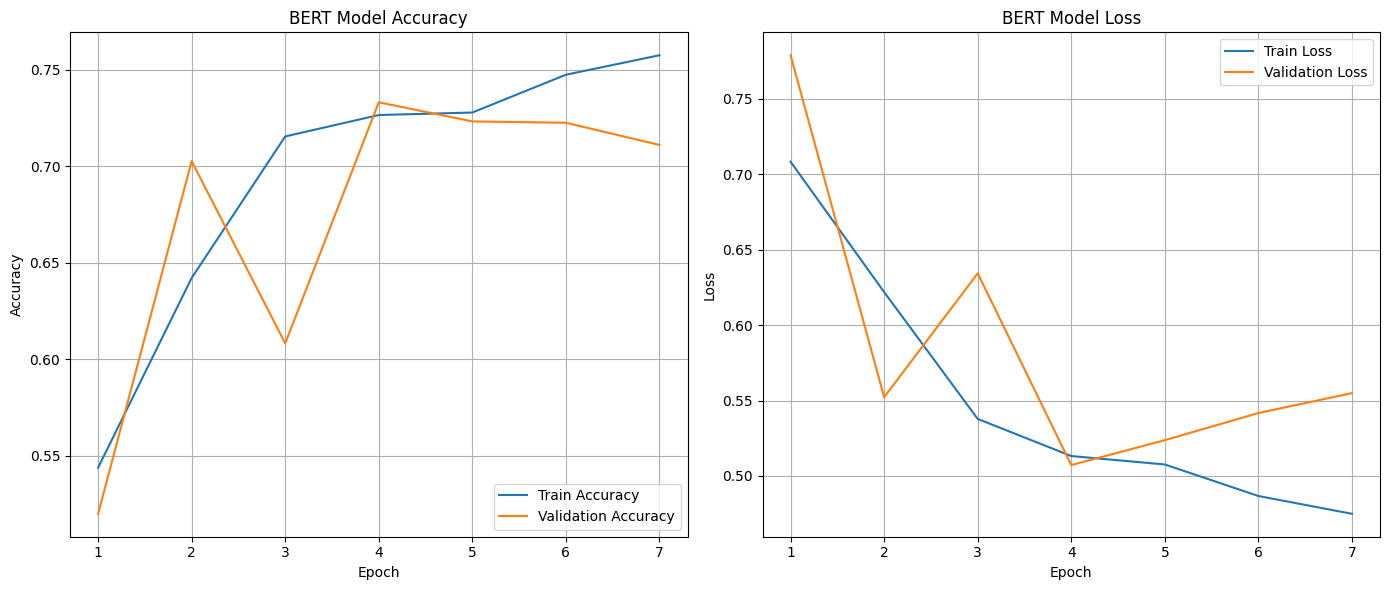

In [32]:
import matplotlib.pyplot as plt

# Data extracted from the output of the BERT training loop (cell tZhaYkyVa35H)
epochs_run = [1, 2, 3, 4, 5, 6, 7]
train_accuracy = [0.5437, 0.6421, 0.7155, 0.7266, 0.7279, 0.7475, 0.7576]
val_accuracy = [0.5198, 0.7027, 0.6082, 0.7332, 0.7233, 0.7226, 0.7111]
train_loss = [0.7083, 0.6219, 0.5378, 0.5132, 0.5076, 0.4867, 0.4749]
val_loss = [0.7789, 0.5522, 0.6343, 0.5072, 0.5237, 0.5417, 0.5549]

plt.figure(figsize=(14, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(epochs_run, train_accuracy, label='Train Accuracy')
plt.plot(epochs_run, val_accuracy, label='Validation Accuracy')
plt.title('BERT Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(epochs_run, train_loss, label='Train Loss')
plt.plot(epochs_run, val_loss, label='Validation Loss')
plt.title('BERT Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Calculate precision, recall, and F1-score
precision = precision_score(all_true_labels, all_predictions)
recall = recall_score(all_true_labels, all_predictions)
f1 = f1_score(all_true_labels, all_predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Or a more comprehensive report
print("\nClassification Report:")
print(classification_report(all_true_labels, all_predictions, target_names=class_names))

Precision: 0.7726
Recall: 0.7899
F1-Score: 0.7812

Classification Report:
                              precision    recall  f1-score   support

False/Barely-True/Pants-Fire       0.72      0.70      0.71       553
  Half-True/Mostly-True/True       0.77      0.79      0.78       714

                    accuracy                           0.75      1267
                   macro avg       0.75      0.74      0.75      1267
                weighted avg       0.75      0.75      0.75      1267

